# Day 47 — Subclassing API, Callbacks

- Build models with the Keras Subclassing API.
- Understand Sequential vs Functional vs Subclassing.
- Save and restore models and weights.
- Use EarlyStopping and ModelCheckpoint.
- Create TensorBoard logs.
- Tune layers, neurons, learning rate, and batch size.
- Evaluate the final model correctly.


## 1. Imports

In [24]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

keras.utils.set_random_seed(42)
np.random.seed(42)


TensorFlow: 2.21.0


## 2. Load the California Housing dataset

We use a standard regression dataset so today's focus stays on the Keras model-development workflow.

In [25]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print("Training:", X_train_scaled.shape)
print("Validation:", X_valid_scaled.shape)
print("Test:", X_test_scaled.shape)


Training: (13209, 8)
Validation: (3303, 8)
Test: (4128, 8)


## 3. API comparison

| API | Main use |
|---|---|
| **Sequential** | Simple stack of layers |
| **Functional** | Complex graphs, multiple inputs/outputs |
| **Subclassing** | Custom or dynamic model behavior |

Today we focus on **Subclassing**.

## 4. Subclassing API

A subclassed Keras model inherits from `keras.Model`.

- `__init__()` defines the layers.
- `call()` defines the forward pass.

In [26]:
class RegressionModel(keras.Model):
    def __init__(self, hidden_units=64, **kwargs):
        # Accept extra kwargs (e.g., trainable, dtype, name) for proper deserialization
        super().__init__(**kwargs)

        self.hidden_units = hidden_units

        self.hidden1 = layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.hidden2 = layers.Dense(
            max(1, hidden_units // 2),
            activation="relu",
        )

        self.output_layer = layers.Dense(1)

    def call(self, inputs, training=None):
        x = self.hidden1(inputs)
        x = self.hidden2(x)
        return self.output_layer(x)

    def get_config(self):
        # Include constructor args so Keras can recreate the model from config
        base_config = super().get_config()
        return {**base_config, "hidden_units": self.hidden_units}

    @classmethod
    def from_config(cls, config):
        # Keras may include keys like 'trainable'/'dtype' in config; pass them through
        return cls(**config)


model = RegressionModel(hidden_units=64)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"],
)

# Build the model so summary() can display it.
model.build((None, X_train_scaled.shape[1]))

model.summary()


c:\Users\Puneeth\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'regression_model_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "regression_model_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Train the subclassed model

In [27]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30


413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9514 - mae: 0.6712 - val_loss: 0.4380 - val_mae: 0.4739
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - loss: 0.3941 - mae: 0.4466 - val_loss: 0.3868 - val_mae: 0.4478
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - loss: 0.3674 - mae: 0.4291 - val_loss: 0.3729 - val_mae: 0.4412
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - loss: 0.3525 - mae: 0.4197 - val_loss: 0.3712 - val_mae: 0.4373
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - loss: 0.3569 - mae: 0.4143 - val_loss: 0.3838 - val_mae: 0.4407
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 0.3376 - mae: 0.4070 - val_loss: 0.3526 - val_mae: 0.4251
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - loss: 0.3270 - mae: 0.4007 - val_loss: 0.3460 - val_mae: 0.4204
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - loss: 0.3216 - mae: 0.3961 - val_loss: 0.3413 - val_mae: 0.4175
Epoch 9/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step

## 6. Plot training and validation loss

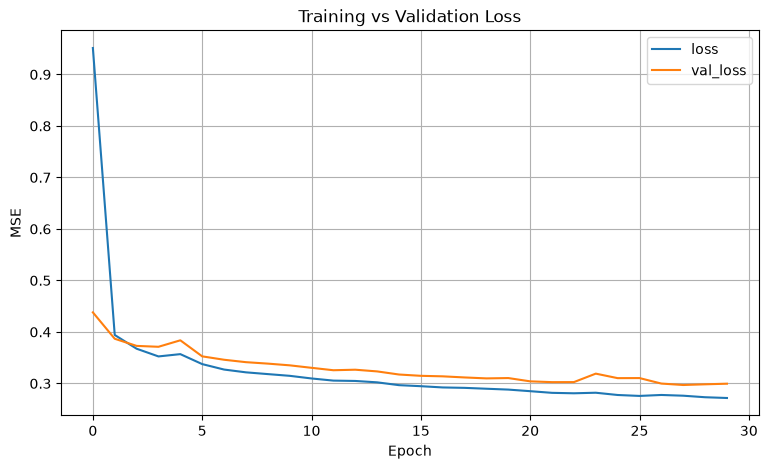

In [28]:
history_df = pd.DataFrame(history.history)

history_df[["loss", "val_loss"]].plot(
    figsize=(9, 5),
    title="Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()


## 7. Save the complete model

The modern Keras format is `.keras`.

For subclassed models, the custom Python class should be available when loading the model.

In [29]:
model_path = "day47_subclassed_regression.keras"

model.save(model_path)

print("Saved:", model_path)
print("Exists:", os.path.exists(model_path))


Saved: day47_subclassed_regression.keras
Exists: True


In [30]:
restored_model = keras.models.load_model(
    model_path,
    custom_objects={"RegressionModel": RegressionModel}
)

test_results = restored_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Restored model test loss:", test_results[0])
print("Restored model test MAE:", test_results[1])


Restored model test loss: 0.2965492904186249
Restored model test MAE: 0.3806806206703186


## 8. Save and restore weights only

In [31]:
weights_path = "day47_regression.weights.h5"

model.save_weights(weights_path)

print("Weights saved:", os.path.exists(weights_path))


Weights saved: True


In [32]:
weights_model = RegressionModel(hidden_units=64)

weights_model.build(
    (None, X_train_scaled.shape[1])
)

weights_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

weights_model.load_weights(weights_path)

print("Weights successfully restored.")


Weights successfully restored.


c:\Users\Puneeth\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'regression_model_10', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Puneeth\anaconda3\envs\tf_env\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_10', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(store)


## 9. EarlyStopping

`EarlyStopping` stops training when the monitored validation metric stops improving.

`restore_best_weights=True` restores the weights from the best epoch.

In [33]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

early_model = RegressionModel(hidden_units=64)

early_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

early_history = early_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("Epochs actually trained:",
      len(early_history.history["loss"]))


Epoch 1/100


413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0729 - mae: 0.7024 - val_loss: 0.4811 - val_mae: 0.4888
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 0.4024 - mae: 0.4494 - val_loss: 0.3959 - val_mae: 0.4492
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - loss: 0.3714 - mae: 0.4266 - val_loss: 0.3759 - val_mae: 0.4382
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - loss: 0.3538 - mae: 0.4156 - val_loss: 0.3649 - val_mae: 0.4301
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - loss: 0.3417 - mae: 0.4076 - val_loss: 0.3553 - val_mae: 0.4235
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step - loss: 0.3355 - mae: 0.4009 - val_loss: 0.3540 - val_mae: 0.4235
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 0.3251 - mae: 0.3951 - val_loss: 0.3426 - val_mae: 0.4164
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - loss: 0.3175 - mae: 0.3900 - val_loss: 0.3367 - val_mae: 0.4124
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 87

## 10. ModelCheckpoint

`ModelCheckpoint` saves the best model during training.

Here we monitor `val_loss` and keep only the best model.

In [34]:
checkpoint_path = "day47_best_model.keras"

checkpoint = keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)

checkpoint_model = RegressionModel(hidden_units=64)

checkpoint_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

checkpoint_history = checkpoint_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=1
)

print("Best model saved:", os.path.exists(checkpoint_path))


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8279 - mae: 0.6222 - val_loss: 0.4635 - val_mae: 0.4786
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 0.3949 - mae: 0.4406 - val_loss: 0.3824 - val_mae: 0.4484
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.3638 - mae: 0.4228 - val_loss: 0.3686 - val_mae: 0.4381
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3463 - mae: 0.4127 - val_loss: 0.3597 - val_mae: 0.4325
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - loss: 0.3461 - mae: 0.4063 - val_loss: 0.3614 - val_mae: 0.4350
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - loss: 0.3405 - mae: 0.4010 - val_loss: 0.3589 - val_mae: 0.4295
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - loss: 0.3271 - mae: 0.3953 - val_loss: 0.3440 - val_mae: 0.4201
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3167 - mae: 0.3905 - val_loss: 0.3344 - val_mae: 0.4141
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms

## 11. Combine EarlyStopping + ModelCheckpoint

This is a practical training pattern:

1. Train for a generous maximum number of epochs.
2. Save the best validation model.
3. Stop when validation performance stops improving.

In [35]:
combined_path = "day47_best_with_early_stopping.keras"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        combined_path,
        monitor="val_loss",
        save_best_only=True
    )
]

combined_model = RegressionModel(hidden_units=64)

combined_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

combined_history = combined_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("Epochs trained:",
      len(combined_history.history["loss"]))


Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9768 - mae: 0.6689 - val_loss: 0.4483 - val_mae: 0.4824
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3991 - mae: 0.4496 - val_loss: 0.3891 - val_mae: 0.4495
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3720 - mae: 0.4309 - val_loss: 0.3757 - val_mae: 0.4421
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3601 - mae: 0.4212 - val_loss: 0.3704 - val_mae: 0.4375
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3463 - mae: 0.4127 - val_loss: 0.3601 - val_mae: 0.4300
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3348 - mae: 0.4053 - val_loss: 0.3507 - val_mae: 0.4249
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3276 - mae: 0.3994 - val_loss: 0.3449 - val_mae: 0.4227
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3290 - mae: 0.3952 - val_loss: 0.3492 - val_mae: 0.4225
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/

## 12. TensorBoard

TensorBoard visualizes training information such as loss and metrics.

We create a separate timestamped directory for this run.

In [36]:
run_name = time.strftime(
    "run_%Y_%m_%d-%H_%M_%S"
)

log_dir = os.path.join(
    "day47_tensorboard_logs",
    run_name
)

# Try to create a TensorBoard callback; if TensorBoard isn't installed, fall back.
try:
    tensorboard_callback = keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=0,
        profile_batch=0,
    )
    callbacks = [tensorboard_callback]
except Exception as e:
    print("TensorBoard callback unavailable — continuing without it.")
    print(type(e).__name__, e)
    callbacks = []

tb_model = RegressionModel(hidden_units=64)

tb_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"],
)

# Try training with the callback; if it raises (e.g., TBNotInstalledError), retry without callbacks.
try:
    tb_history = tb_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=30,
        batch_size=32,
        callbacks=callbacks,
        verbose=1,
    )
except Exception as e:
    print("Training with TensorBoard callback failed — retrying without callbacks.")
    print(type(e).__name__, e)
    tb_history = tb_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=30,
        batch_size=32,
        callbacks=[],
        verbose=1,
    )

if callbacks:
    print("TensorBoard log directory:")
    print(log_dir)
else:
    print("TensorBoard not used; no log directory created.")


Epoch 1/30
Training with TensorBoard callback failed — retrying without callbacks.
TBNotInstalledError TensorBoard is not installed, missing implementation for tf.summary.scalar
Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8063 - mae: 0.6170 - val_loss: 0.4533 - val_mae: 0.4786
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3940 - mae: 0.4468 - val_loss: 0.3868 - val_mae: 0.4477
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3622 - mae: 0.4268 - val_loss: 0.3746 - val_mae: 0.4386
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3485 - mae: 0.4155 - val_loss: 0.3603 - val_mae: 0.4304
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3354 - mae: 0.4063 - val_loss: 0.3513 - val_mae: 0.4221
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3238 - mae: 0.3986 - val_loss: 0.3462 - val_mae: 0.4159
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3151 - mae: 0.3928 - val_loss: 0.3377 - val_mae: 0.4

### Launch TensorBoard

From Anaconda Prompt / terminal:

```bash
tensorboard --logdir=day47_tensorboard_logs
```

Or, inside Jupyter:

```python
%load_ext tensorboard
%tensorboard --logdir day47_tensorboard_logs
```

The TensorBoard dashboard lets you inspect training and validation metrics.

In [37]:
# If TensorBoard is installed, uncomment these two lines:

# %load_ext tensorboard
# %tensorboard --logdir day47_tensorboard_logs


## 13. Hyperparameter tuning

Important hyperparameters include:

- Number of hidden layers
- Number of neurons
- Learning rate
- Batch size
- Optimizer
- Activation function
- Regularization
- Training duration

We will perform a small manual search.

In [38]:
def build_tunable_model(
    hidden_units=64,
    learning_rate=0.001,
    n_hidden=2
):
    class TunableRegressionModel(keras.Model):

        def __init__(self):
            super().__init__()

            self.hidden_layers = [
                layers.Dense(
                    hidden_units,
                    activation="relu"
                )
                for _ in range(n_hidden)
            ]

            self.output_layer = layers.Dense(1)

        def call(self, inputs, training=None):
            x = inputs

            for layer in self.hidden_layers:
                x = layer(x)

            return self.output_layer(x)

    model = TunableRegressionModel()

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


## 14. Hyperparameter experiment — learning rate

In [39]:
learning_rates = [0.0005, 0.001, 0.005]

learning_rate_results = []

for lr in learning_rates:

    keras.utils.set_random_seed(42)

    experiment_model = build_tunable_model(
        hidden_units=64,
        learning_rate=lr,
        n_hidden=2
    )

    experiment_history = experiment_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=30,
        batch_size=32,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    learning_rate_results.append({
        "learning_rate": lr,
        "best_val_loss": min(
            experiment_history.history["val_loss"]
        ),
        "epochs": len(
            experiment_history.history["loss"]
        )
    })

learning_rate_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_df


,learning_rate,best_val_loss,epochs
0,0.0005,0.301760,30
1,0.0010,0.290170,30
2,0.0050,0.285572,30


## 15. Hyperparameter experiment — number of neurons

In [40]:
hidden_units_list = [32, 64, 128]

neuron_results = []

for units in hidden_units_list:

    keras.utils.set_random_seed(42)

    experiment_model = build_tunable_model(
        hidden_units=units,
        learning_rate=0.001,
        n_hidden=2
    )

    experiment_history = experiment_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=30,
        batch_size=32,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    neuron_results.append({
        "hidden_units": units,
        "best_val_loss": min(
            experiment_history.history["val_loss"]
        ),
        "epochs": len(
            experiment_history.history["loss"]
        )
    })

neuron_df = pd.DataFrame(neuron_results)

neuron_df


,hidden_units,best_val_loss,epochs
0,32,0.308395,30
1,64,0.290170,30
2,128,0.278454,30


## 16. Hyperparameter experiment — batch size

In [41]:
batch_sizes = [16, 32, 64]

batch_results = []

for batch_size in batch_sizes:

    keras.utils.set_random_seed(42)

    experiment_model = build_tunable_model(
        hidden_units=64,
        learning_rate=0.001,
        n_hidden=2
    )

    experiment_history = experiment_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=30,
        batch_size=batch_size,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    batch_results.append({
        "batch_size": batch_size,
        "best_val_loss": min(
            experiment_history.history["val_loss"]
        ),
        "epochs": len(
            experiment_history.history["loss"]
        )
    })

batch_df = pd.DataFrame(batch_results)

batch_df


,batch_size,best_val_loss,epochs
0,16,0.318937,14
1,32,0.290170,30
2,64,0.301730,30


## 17. Compare tuning results

These values are produced by **your own TensorFlow run**. Do not memorize the exact numbers; focus on how changing hyperparameters affects validation performance.

In [42]:
print("Learning rate:")
display(learning_rate_df)

print("Number of neurons:")
display(neuron_df)

print("Batch size:")
display(batch_df)


Learning rate:


,learning_rate,best_val_loss,epochs
0,0.0005,0.301760,30
1,0.0010,0.290170,30
2,0.0050,0.285572,30


Number of neurons:


,hidden_units,best_val_loss,epochs
0,32,0.308395,30
1,64,0.290170,30
2,128,0.278454,30


Batch size:


,batch_size,best_val_loss,epochs
0,16,0.318937,14
1,32,0.290170,30
2,64,0.301730,30


## 18. Final test evaluation

The test set should be used for the final unbiased evaluation, not repeatedly for hyperparameter selection.

In [43]:
test_loss, test_mae = combined_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Test MSE: 0.2780
Test MAE: 0.3652


## 19. Make predictions

In [44]:
predictions = combined_model.predict(
    X_test_scaled[:10],
    verbose=0
).ravel()

comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].to_numpy(),
    "Predicted": predictions
})

comparison["Absolute Error"] = (
    comparison["Actual"] -
    comparison["Predicted"]
).abs()

comparison


,Actual,Predicted,Absolute Error
0,0.47700,0.500761,0.023761
1,0.45800,1.456209,0.998209
2,5.00001,4.723200,0.276810
3,2.18600,2.634354,0.448354
4,2.78000,2.728896,0.051104
5,1.58700,1.640942,0.053942
6,1.98200,2.452519,0.470519
7,1.57500,1.603489,0.028489
8,3.40000,2.825674,0.574326
9,4.46600,4.591971,0.125971


# Quick Revision

```text
Sequential
    ↓
Simple layer stack

Functional
    ↓
Complex connected architecture

Subclassing
    ↓
Custom / dynamic behavior


Training
    ↓
Callbacks
    ├── EarlyStopping
    ├── ModelCheckpoint
    └── TensorBoard

Hyperparameter tuning
    ├── Layers
    ├── Neurons
    ├── Learning rate
    ├── Batch size
    ├── Optimizer
    └── Regularization

Final workflow
    ↓
Build → Compile → Train → Monitor
→ Checkpoint → Tune → Test → Save
```
